# High-Resolution, Spinal Cord Stimulation for Non-Opioid Treatment of Neuropathic Pain

Prepared by:
: J M Maxwell, Center for Translational Data Science (CTDS), University of Chicago

:::{note} Attribution
:class: dropdown
This notebook uses data collected by [](10.1016/j.neurom.2024.08.004) as part of their study entitled *Correlating Evoked Electromyography and Anatomic Factors During Spinal Cord Stimulation Implantation With Short-Term Outcomes*. The data have been archived by the authors at [Mendeley Data](10.17632/rmj2kngzbp.1) and are accessible via the [HEAL Data Platform](https://healdata.org/portal/discovery/HDP00384/).

The purpose of this notebook is to demonstrate how the data may be accessed and used for analysis, and is intended to be used as a jumping off point for researchers who may wish to use these data for their own secondary analyses. While some of the analyses below may recreate analyses presented in the original publication, they are not intended to replicate the original results and differences in analytic methods and software, selection/filtering of observations, and handling of missing data may yield results that differ from the original.

The work here was conducted without direct involvement of the original authors and therefore does not necessarily reflect the views or opinions of the authors, of the NIH HEAL Initiative&reg;, or of the Center for Translational Data Science (CTDS) at the University of Chicago.
:::

## About the Study

The study, *High-Resolution, Spinal Cord Stimulation for Non-Opioid Treatment of Neuropathic Pain*, investigated the outcomes of elliciting EMGs (electromyography) in subject's regions of pain during surgery. Data for evaluating the treatment effect were collected from 21 patients in two phases. Subject outcomes were measured using: the Numerical Rating Scale, McGill Pain Questionnaire, Beck Depression Inventory, Oswestry Disability Index, and Pain Catastrophizing Score, and were recorded preoperatively and at three months following the procedure. 

## Setup

This notebook uses Python (tested with version 3.13) and relies on several modules and third-party packages. Thus we start by installing and/or importing these if necessary (click on the bar below to expand the cell and see the code).

In [1]:
!pip install pandas openpyxl gen3 tableone scipy matplotlib -q
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, Image, display

## Retrieving the Data

The data used here are archived at [Mendeley Data](10.17632/rmj2kngzbp.1). Accessing these data through the Platform currently requires that you login using one of the options provided. After doing so, you may download the data directly from the [Study Page](https://healdata.org/portal/discovery/HDP00384) (under the Data tab) or you may download them using the ``gen3`` command, as we will do here.

Each file indexed by the Platform is assigned a globally unique identifier (GUID) that may be used to retrieve the file. Here we download two files using their GUIDs.

:::{note}
We use an if condition to avoid downloading the file each time we re-run the notebook.
:::

In [2]:
if not os.path.exists('Microleads - Participant level data.xlsx'):
    !gen3 drs-pull object dg.H34L/b8b871b8-aadd-4017-9f67-184b17ab3580
if not os.path.exists('Pain-MRI scores.xlsx'):
    !gen3 drs-pull object dg.H34L/ffde8647-1ec2-4459-8409-bd41c0736c86

### Reading and Cleaning the Data

After reading in the data, we perform standard data cleaning steps to improve the usability of the data, remove extraneous data features, and engineer new features measuring the percent change in treatment effects from before and after the each sample subject's operation.

In [3]:
participants_df = pd.read_excel('Microleads - Participant level data.xlsx')
pain_scores_df = pd.read_excel('Pain-MRI scores.xlsx')
pain_scores_df = pain_scores_df.iloc[:21, :]
df = pd.merge(left=participants_df, right=pain_scores_df, how='left', on=['Phase', 'Patient'])
df[list(df.select_dtypes(include='float64'))] = df[list(df.select_dtypes(include='float64'))].astype('float32')
df.replace('-', np.nan, inplace=True)
df.rename(columns={'NRS Pre-op': 'NRS Pre-Op', 'NRS Post-op': 'NRS Post-Op', 'MPQ pre-op': 'MPQ Pre-Op', 'MPQ post-op': 'MPQ Post-Op', 'Gender': 'Sex'}, inplace=True)
df.drop(['Patient', 'Race', 'Ethnicity', 'Age Unit'], axis=1, inplace=True)

delta_cols = ['NRS', 'MPQ', 'ODI', 'PCS', 'BDI']
for col in delta_cols:
    df[f'{col}_pct_change'] = np.round(100*((df[f'{col} Post-Op'].astype('float') - df[f'{col} Pre-Op'].astype('float'))/df[f'{col} Post-Op'].astype('float')), 2)
df.replace(np.float64('-inf'), np.nan, inplace=True)

,Phase,Sex,Age,NRS Pre-Op,NRS Post-Op,MPQ Pre-Op,MPQ Post-Op,ODI Pre-Op,ODI Post-Op,PCS Pre-Op,...,BDI Pre-Op,BDI Post-Op,AP column Diameter (mm),Interpedicular distance (mm),Dorsal CSF Thickness (mm),NRS_pct_change,MPQ_pct_change,ODI_pct_change,PCS_pct_change,BDI_pct_change
0,1,F,54,9.0,4,6.0,6,68.000000,44,14.0,...,10.0,5,12.8,16.5,3,-125.00,0.00,-54.55,-100.00,-100.00
1,1,M,60,9.0,5,8.0,7,62.000000,36,34.0,...,15.0,11,15.8,20,4,-80.00,-14.29,-72.22,-112.50,-36.36
2,1,M,46,7.0,3,9.0,8,54.000000,30,17.0,...,17.0,7,11.3,14.8,2.5,-133.33,-12.50,-80.00,-325.00,-142.86
3,1,M,29,8.0,5,9.0,5,52.000000,54,20.0,...,5.0,8,15.2,19.5,5,-60.00,-80.00,3.70,-185.71,37.50
4,1,F,43,8.0,3,6.0,5,78.000000,NaN,42.0,...,46.0,23,14.8,19.6,5,-166.67,-20.00,NaN,-10.53,-100.00
5,1,F,40,2.0,0,5.0,NaN,12.000000,NaN,2.0,...,4.0,NaN,17,21.5,4.8,NaN,NaN,NaN,NaN,NaN
6,1,F,52,7.0,8,4.0,5,60.000000,62,2.0,...,7.0,16,17.6,18.8,3.9,12.50,20.00,3.23,92.31,56.25
7,1,M,67,6.0,4,1.0,NaN,62.000000,NaN,24.0,...,19.0,NaN,19,19.3,5.3,-50.00,NaN,NaN,NaN,NaN
8,1,F,57,7.0,7,1.0,14,73.000000,74,14.0,...,16.0,5,18.1,20,5.4,0.00,92.86,1.35,-133.33,-220.00
9,1,F,36,10.0,8,9.0,13,76.000000,76,39.0,...,34.0,40,17,21.8,5.7,-25.00,30.77,0.00,-69.57,15.00


## Summary Statistics

First, let us look at the summary statistics for our measured treatment effects and our engineer treatment effects.

In [4]:
characteristics = ['Sex M/F', 'Age', 'Anterior-posterior diameter (mean ± SD in mm)',
                   'Interpedicular distance (mean ± SD in mm)', 'Dorsal CSF thickness (mean ± SD in mm)',
                   'Numerical Rating Scale (mean ± SD)', 'McGill Pain Questionnaire (mean ± SD)',
                   'Oswestry Disability Index (mean ± SD)', 'Pain Catastrophizing Scale (mean ± SD)', 'Beck Depression Index (mean ± SD']

cols = ['Age', 'AP column Diameter (mm)', 'Interpedicular distance (mm)', 'Dorsal CSF Thickness (mm)',
        'NRS Pre-Op', 'MPQ Pre-Op',  'ODI Pre-Op',  'PCS Pre-Op',  'BDI Pre-Op', ]

x = df.Sex.value_counts().values
values = [f'{int(x[1])} / {int(x[0])}']
for col in cols:
    values.append(f'{np.round(float(df[col].mean()), decimals=1)} ' + u"\u00B1" + f' {np.round(float(df[col].std()), 1)}')

pd.DataFrame({'Patient Information and Clinical Characteristics': characteristics, 'Values': values}).style.hide(axis='index')

Patient Information and Clinical Characteristics,Values
Sex M/F,7 / 14
Age,56.0 ± 14.6
Anterior-posterior diameter (mean ± SD in mm),15.1 ± 2.1
Interpedicular distance (mean ± SD in mm),19.1 ± 1.9
Dorsal CSF thickness (mean ± SD in mm),4.5 ± 1.0
Numerical Rating Scale (mean ± SD),7.3 ± 1.7
McGill Pain Questionnaire (mean ± SD),7.9 ± 5.5
Oswestry Disability Index (mean ± SD),55.2 ± 16.0
Pain Catastrophizing Scale (mean ± SD),23.9 ± 12.6
Beck Depression Index (mean ± SD,16.0 ± 11.7


In [5]:
characteristics = ['Numerical Rating Scale Percent Change (mean ± SD)', 'McGill Pain Questionnaire Percent Change (mean ± SD)',
                   'Oswestry Disability Index Percent Change (mean ± SD)', 'Pain Catastrophizing Scale Percent Change (mean ± SD)',
                   'Beck Depression Index Percent Change (mean ± SD']

cols = ['NRS_pct_change', 'MPQ_pct_change', 'ODI_pct_change', 'PCS_pct_change', 'BDI_pct_change']
values = []
for col in cols:
    values.append(f'{np.round(float(df[col].mean()), decimals=1)} ' + u"\u00B1" + f' {np.round(float(df[col].std()), 1)}')

pd.DataFrame({'Patient Information and Clinical Characteristics': characteristics, 'Values': values}).style.hide(axis='index')

Patient Information and Clinical Characteristics,Values
Numerical Rating Scale Percent Change (mean ± SD),-95.1 ± 87.5
McGill Pain Questionnaire Percent Change (mean ± SD),-36.0 ± 90.8
Oswestry Disability Index Percent Change (mean ± SD),-72.0 ± 158.0
Pain Catastrophizing Scale Percent Change (mean ± SD),-174.5 ± 434.1
Beck Depression Index Percent Change (mean ± SD,-59.0 ± 113.6


## Statistical Testing

We're interested in comparing the treatment effects pre and post subject's operations. To begin with, we can use the Shapiro-Wilk Test to determine if the differences between each set of distributions are potentially normally distributed. 

The null hypothesis is that the difference between the distributions of each treatment effect pre and post operation are not normally distributed. If we reject the null hypothesis, then we will proceed assuming the difference in distributions is not normally distributed. If we fail to reject the null hypothesis, then we will assume the distributions could be normally distributed.

Shapiro-Wilk Test: NRS 
Statistic: 0.958 
P-value: 0.513
Sample NRS could be normally distributed (fail to reject null hypothesis)
********************** 

Shapiro-Wilk Test: MPQ 
Statistic: 0.957 
P-value: 0.55
Sample MPQ could be normally distributed (fail to reject null hypothesis)
********************** 

Shapiro-Wilk Test: ODI 
Statistic: 0.862 
P-value: 0.016
Sample ODI does not look normally distributed (reject null hypothesis)
********************** 

Shapiro-Wilk Test: PCS 
Statistic: 0.881 
P-value: 0.027
Sample PCS does not look normally distributed (reject null hypothesis)
********************** 

Shapiro-Wilk Test: BDI 
Statistic: 0.96 
P-value: 0.607
Sample BDI could be normally distributed (fail to reject null hypothesis)
********************** 



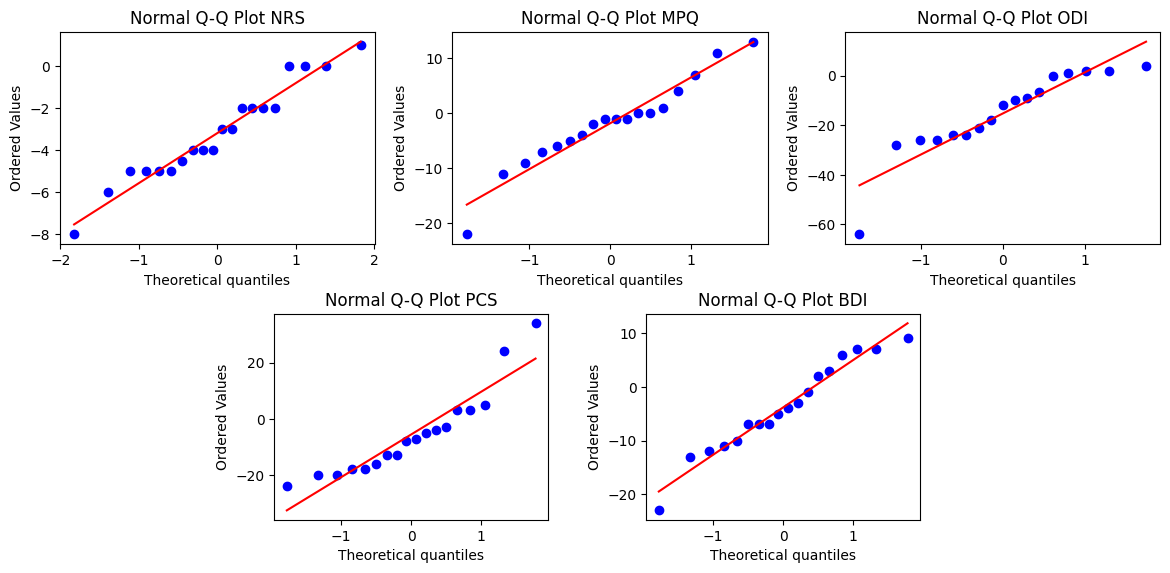

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))  # Adjust the figure size as needed
axes = axes.flatten()

delta_cols = ['NRS', 'MPQ', 'ODI', 'PCS', 'BDI']
for i in range(0, len(delta_cols)):

    data = (df[f'{delta_cols[i]} Post-Op'] - df[f'{delta_cols[i]} Pre-Op']).dropna().astype('float')
    stat, p = stats.shapiro(data)

    print(f'Shapiro-Wilk Test: {delta_cols[i]} \nStatistic: {np.round(stat, 3)} \nP-value: {np.round(p, 3)}')
    if p >  0.05:
        print(f'Sample {delta_cols[i]} could be normally distributed (fail to reject null hypothesis)')
    else:
        print(f'Sample {delta_cols[i]} does not look normally distributed (reject null hypothesis)')
    print("********************** \n")

    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f"Normal Q-Q Plot {delta_cols[i]}")

plt.tight_layout()
axes[3].set_position([0.24,0.125,0.228,0.343])
axes[4].set_position([0.55,0.125,0.228,0.343])
axes[5].set_visible(False)
plt.show()

For three of the subjects' measured treatment effects, Numerical Rating Scale (NRS), McGill Pain Questionnairre (MPQ), and Beck Depression Index (BDI), we fail to reject the [null hypothesis](#h1) and so the differences between effects pre and post operation could be normally distributed. For these three we will test if the underlying distributions of the treatment effects pre and post operation have the same underlying distribution using the Student's t-test.

For the other two measured treatment effects, Oswestry Disability Index (ODI) and Pain Catastrophizing Scale (PCS), we reject the null hypthesis and assume the difference between treatment effects pre and post operation are not normally distributed. For these two treatment effects we cannot use the Student's t-test, and will instead use the non-parametric Mann Whitney U Test to test whether the the pre and post operation treatment effect samples hace the same underlying distribution. Because the Mann Whitney U Test is a non-parametric statistical test that does not assume normality, we will also use this test on the other three treatment effects.

### Student's T-Test

The Two-Sample, Paired Student's T-Test is used to test whether two related, sample distributions have a statistically significant difference. 

Our null hypothesis is that the averages (or expected) values of the two samples, pre and post treatment effects, are the same.

If the null hypothesis is rejected, then the pre and post operation treatment effect samples do not have identical average (expected) values and the pre and post operation samples could be different, or in other words, the operation may have influenced a change in the measured treatment effect.

If we fail to reject the null hypothesis, then the pre and post operation treatment effect samples could have identical average (expected) values and the operation may not have influenced a change in the measured treatment effect.

In [7]:
delta_cols = ['NRS', 'MPQ', 'BDI']
for col in delta_cols:
    df[f'{col} Pre-Op'] = df[f'{col} Pre-Op'].astype('float')
    df[f'{col} Post-Op'] = df[f'{col} Post-Op'].astype('float')
    resultTtest = stats.ttest_rel(a=df[f'{col} Pre-Op'], b=df[f'{col} Post-Op'], nan_policy='omit')

    print(f"Student's t Test: {col} \nStatistic: {np.round(resultTtest.statistic, 3)} \nP-value: {np.round(resultTtest.pvalue, 3)}")
    if resultTtest.pvalue >  0.05:
        print(f'Pre and Post Op {col} samples could have identical average (expected) values. (fail to reject null hypothesis)')
    else:
        print(f'Pre and Post Op {col} samples do not have identical average (expected) values. (reject null hypothesis)')
    print("********************** \n")

Student's t Test: NRS 
Statistic: 6.139 
P-value: 0.0
Pre and Post Op NRS samples do not have identical average (expected) values. (reject null hypothesis)
********************** 

Student's t Test: MPQ 
Statistic: 0.961 
P-value: 0.35
Pre and Post Op MPQ samples could have identical average (expected) values. (fail to reject null hypothesis)
********************** 

Student's t Test: BDI 
Statistic: 1.916 
P-value: 0.072
Pre and Post Op BDI samples could have identical average (expected) values. (fail to reject null hypothesis)
********************** 



We only reject the null hypothesis for the first treatment effect, Numerical Rating Scale (NRS), and fail to reject the null hypothesis for the other two treatment effects McGill Pain Questionnairre (MPQ) and Beck Depression Index (BDI).

### Wilcoxon Signed-Rank Test

The Wilcoxon Signed-Rank Test is a non-parametric version of the Student's T-Test used to test if there is a difference between two paired distributions. 

It tests the null hypothesis that differences between the paired samples are distributed symetrically around zero. 
If we reject the null hypothesis, then the paired pre and post operation treatment effects do not have the same underlying distribution, and the operation could have caused a significant difference to the measured treatment effect. And if we fail to reject the null hypothesis, then the paired treatment effect samples could have the same underlying distribution, and the treatment may not have caused a significant difference to the measured treatment effect.

In [8]:
delta_cols = ['NRS', 'MPQ', 'ODI', 'PCS', 'BDI']
for col in delta_cols:
    df[f'{col} Pre-Op'] = df[f'{col} Pre-Op'].astype('float')
    df[f'{col} Post-Op'] = df[f'{col} Post-Op'].astype('float')
    result_wilcoxon_test = stats.wilcoxon(x=df[f'{col} Pre-Op'], y=df[f'{col} Post-Op'], nan_policy='omit', zero_method='wilcox')

    print(f"Wilcoxon Signed-Rank Test: {col} \nStatistic: {np.round(result_wilcoxon_test.statistic, 3)} \nP-value: {np.round(result_wilcoxon_test.pvalue, 3)}")
    if result_wilcoxon_test.pvalue >  0.05:
        print(f'Pre and Post Op {col} samples could have the same underlying distribution. (fail to reject null hypothesis)')
    else:
        print(f'Pre and Post Op {col} samples do not have the same underlying distribution. (reject null hypothesis)')
    print("********************** \n")

Wilcoxon Signed-Rank Test: NRS 
Statistic: 1.0 
P-value: 0.0
Pre and Post Op NRS samples do not have the same underlying distribution. (reject null hypothesis)
********************** 

Wilcoxon Signed-Rank Test: MPQ 
Statistic: 48.0 
P-value: 0.3
Pre and Post Op MPQ samples could have the same underlying distribution. (fail to reject null hypothesis)
********************** 

Wilcoxon Signed-Rank Test: ODI 
Statistic: 10.0 
P-value: 0.003
Pre and Post Op ODI samples do not have the same underlying distribution. (reject null hypothesis)
********************** 

Wilcoxon Signed-Rank Test: PCS 
Statistic: 44.0 
P-value: 0.07
Pre and Post Op PCS samples could have the same underlying distribution. (fail to reject null hypothesis)
********************** 

Wilcoxon Signed-Rank Test: BDI 
Statistic: 45.5 
P-value: 0.081
Pre and Post Op BDI samples could have the same underlying distribution. (fail to reject null hypothesis)
********************** 



Like with the Student's T-Test, we reject the null hypothesis for treatment effect Numerical Rating Scale (NRS), we also reject the null hypothesis for the treatment effect Oswestry Disability Index (ODI). This suggests that there is a statistically significant difference between these measured treatment effects from before and after the subjects' operations. 

For the other three treatment effects, we fail to reject the null hypothesis, and should conclude that there is no significant differences to the measured treatment effects before and after the subjects' operations.

## Conclusions

*We found large, average percent descreases between pre and post operation data across all five measured treatment effects for subject's reported pain, depression, and pain induced disability.* Using both parametric and non-parametric statistical testing we found there was a statistically significant difference to the subject's pain and disability as reported with the Numerical Rating Scale for pain and the Oswestry Disability Index for lower-back pain induced disability.